In [167]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

#과제 1: 알고리즘 성능 비교
# Iris 데이터로 5가지 알고리즘 모두 실습
# 1번 같은 경우, LDA는 scaling을 해야해서 LDA만 빼고 해주세요. 속도는 정리 안하셔도 됩니다.

In [169]:
iris = load_iris()

In [171]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

In [172]:
#과제 1: 알고리즘 성능 비교
# 1. Decision Tree  
# 2. Logistic Regression
# 3. Naive Bayes
# 4. KNN

In [173]:
# 1. Decision Tree (의사결정 트리)

In [174]:
tree = DecisionTreeClassifier(
    criterion='gini',         
    max_depth=3,              
    min_samples_split=5,    
    min_samples_leaf=2,        
    random_state=42)

In [175]:
tree.fit(X_train, y_train)

train_acc = tree.score(X_train, y_train)
test_acc = tree.score(X_test, y_test)

print("="*60)
print(f"Train Accuracy(정확도): {train_acc:.3f}")
print(f"Test Accuracy(정확도): {test_acc:.3f}")
print("="*60)

Train Accuracy(정확도): 0.950
Test Accuracy(정확도): 1.000


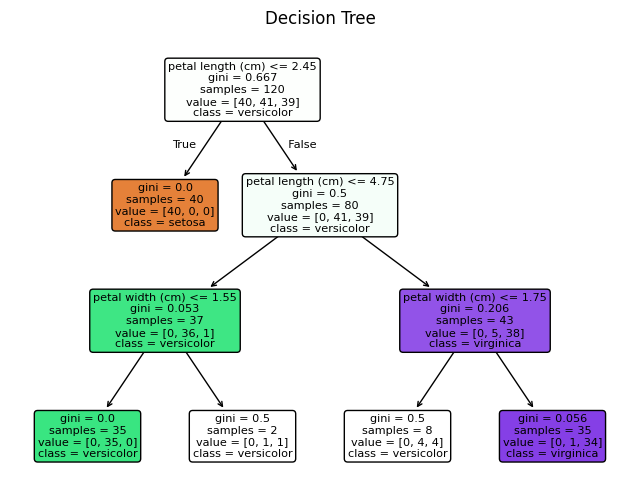

In [176]:
plt.figure(figsize=(8, 6))
plot_tree(tree, 
         feature_names=iris.feature_names,
         class_names=iris.target_names,
         filled=True,           
         rounded=True,         
)
plt.title('Decision Tree')
plt.show()

sepal length (cm): 0.000
sepal width (cm): 0.000
petal length (cm): 0.947
petal width (cm): 0.053


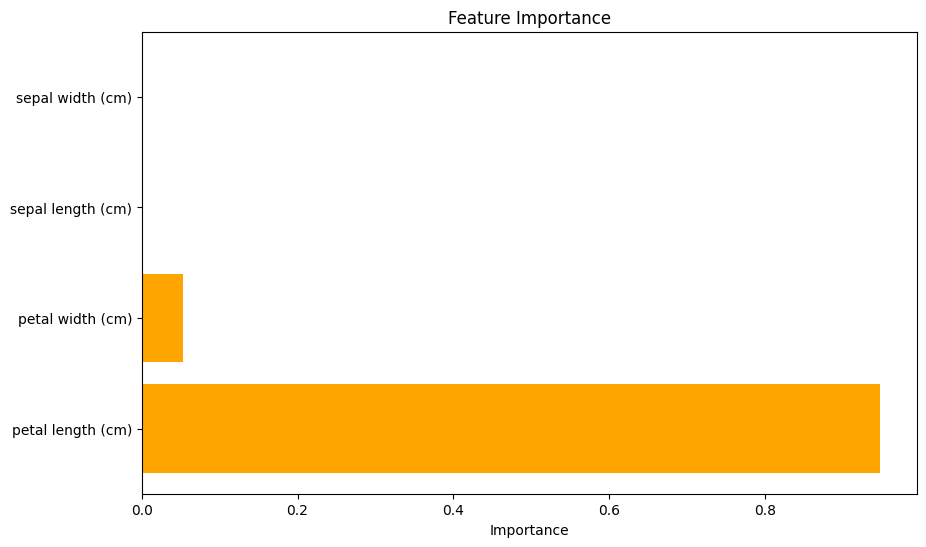

In [177]:
importances = tree.feature_importances_

for name, importance in zip(iris.feature_names, importances):
    print(f"{name}: {importance:.3f}")

importance_df = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'],color="orange")
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

In [178]:
# 2. Logistic Regression
model = LogisticRegression() 
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("="*60)
print(f"Train Accuracy(정확도): {train_acc:.3f}")
print(f"Test Accuracy(정확도): {test_acc:.3f}")
print("="*60)

Train Accuracy(정확도): 0.975
Test Accuracy(정확도): 1.000


In [179]:
# 3.  Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
y_proba = nb.predict_proba(X_test)

accuracy = nb.score(X_test, y_test)

print("="*60)
print(f"Accuracy: {accuracy:.3f}")
print("="*60)
print("처음 5개 샘플의 클래스별 확률:")
print(y_proba[:5])

Accuracy: 1.000
처음 5개 샘플의 클래스별 확률:
[[5.97327448e-090 9.95635767e-001 4.36423302e-003]
 [1.00000000e+000 4.96158126e-014 6.54922363e-021]
 [7.31890302e-290 4.92947614e-012 1.00000000e+000]
 [2.81842533e-094 9.77593559e-001 2.24064412e-002]
 [1.13877801e-105 8.70022596e-001 1.29977404e-001]]


In [180]:
# 4. KNN

In [181]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

train_acc = knn.score(X_train, y_train)
test_acc = knn.score(X_test, y_test)

print("="*60)
print(f"Train Accuracy(정확도): {train_acc:.3f}")
print(f"Test Accuracy(정확도): {test_acc:.3f}")
print("="*60)

distances, indices = knn.kneighbors(X_test[:1])
print("첫 번째 샘플의 5개 이웃:")
print(f"거리: {distances[0]}")
print(f"인덱스: {indices[0]}")
print("="*60)

Train Accuracy(정확도): 0.950
Test Accuracy(정확도): 1.000
첫 번째 샘플의 5개 이웃:
거리: [0.2236068  0.3        0.43588989]
인덱스: [79 90 39]


In [182]:
# 과제 2: Decision Tree 깊이 실험
# max_depth를 3~5까지 바꿔가며 성능 측정 → 그래프로 시각화

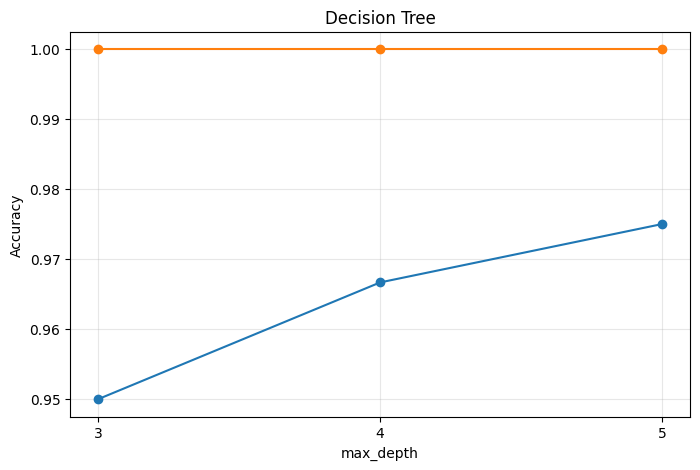

In [183]:
depth_list = [3, 4, 5]

train_scores = []
test_scores = []

for d in depth_list:
    tree = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42)
    
    tree.fit(X_train, y_train)

    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

plt.figure(figsize=(8, 5))
plt.plot(depth_list, train_scores, marker='o', label='Train Accuracy')
plt.plot(depth_list, test_scores, marker='o', label='Test Accuracy')
plt.xticks(depth_list)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree')
plt.grid(True, alpha=0.3)
plt.show()

In [184]:
# 3.KNN 하이퍼파라미터 튜닝
# K값과 거리 측정 방법을 바꿔가며 실험 → 최적 조합 찾기

In [194]:
# 유클리드
best_k = None
best_score = 0

for k in range(1, 31):
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2
    )
    score = cross_val_score(knn, X_train, y_train, cv=5).mean()
    if score > best_score:
        best_score = score
        best_k = k
        
print("="*60)
print("유클리드 거리로 했을 때 최적 K:", best_k)
print(f"그때 점수: {best_score:.3f}")
print("="*60)

유클리드 거리로 했을 때 최적 K: 3
그때 점수: 0.958


In [195]:
# 맨해튼 
best_k = None
best_score = 0.0

for k in range(1, 31):   
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',   
        p=1                  # p=1 이면 맨해튼 거리
    )
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()

    if score > best_score:
        best_score = score
        best_k = k
        
print("="*60)
print("맨해튼 거리로 했을 때 최적 K:", best_k)
print(f"그때 점수: {best_score:.3f}")
print("="*60)

맨해튼 거리로 했을 때 최적 K: 14
그때 점수: 0.967


In [196]:
# 체비쇼프
best_k = None
best_score = 0.0

for k in range(1, 31):  
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='chebyshev' 
    )
    score = cross_val_score(
        knn, X_train, y_train,
        cv=5,
        scoring='accuracy'
    ).mean()

    if score > best_score:
        best_score = score
        best_k = k
        
print("="*60)
print("체비쇼프 거리로 했을 때 최적 K:", best_k)
print(f"그때 점수: {best_score:.3f}")
print("="*60)

체비쇼프 거리로 했을 때 최적 K: 5
그때 점수: 0.967


Best K: 3
Best Score: 0.958


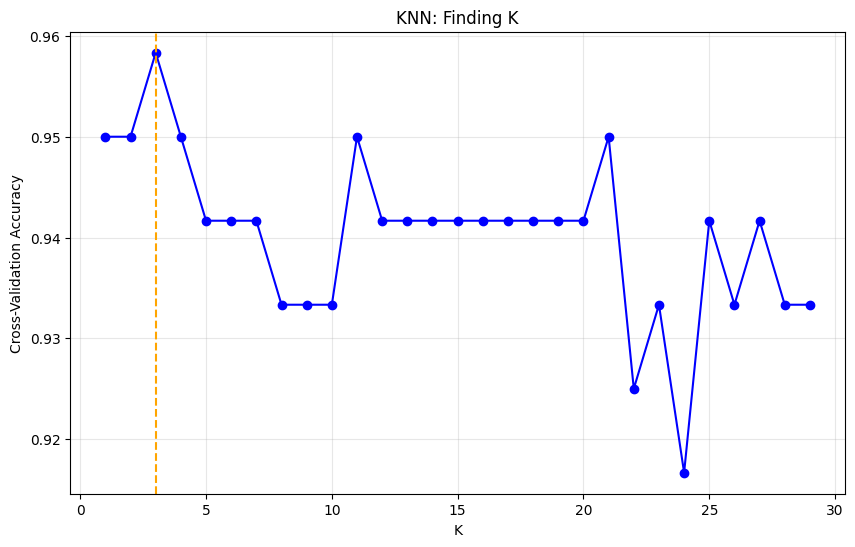

In [197]:
k_range = list(range(1, 30))
scores = []

for k in k_range:
    knn = KNeighborsClassifier(k)
    score = cross_val_score(knn, X_train, y_train, scoring='accuracy').mean()
    scores.append(score)

best_k = k_range[scores.index(max(scores))]

print("="*60)
print(f"Best K: {best_k}")
print(f"Best Score: {max(scores):.3f}")
print("="*60)


plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, 'bo-')           
plt.axvline(x=best_k, color='orange', linestyle='--')
plt.xlabel('K')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN: Finding K')
plt.grid(True, alpha=0.3)
plt.show()